In [1]:
import os
import sys
import subprocess
import importlib.metadata as importlib_metadata

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

IN_KAGGLE = os.path.exists("/kaggle/input")
print(f"Running inside Kaggle: {IN_KAGGLE}")

packages = [
    "transformers>=4.47.1",
    "accelerate>=1.1.0",
    "peft>=0.13.2",
    "bitsandbytes>=0.44.1",
    "qwen-vl-utils>=0.0.8",
    "datasets>=2.20.0",
    "trl>=0.11.4",
    "evaluate>=0.4.3",
    "gradio>=4.44.1",
    "rouge-score>=0.1.2",
    "sentencepiece>=0.2.0",
]

if IN_KAGGLE:
    print("Installing/upgrading Kaggle dependencies. This can take a few minutes...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages])
else:
    print("Not in Kaggle; skipping automatic package installation.")

for pkg in ["torch", "transformers", "accelerate", "peft", "bitsandbytes", "qwen-vl-utils", "datasets", "trl", "gradio"]:
    try:
        print(f"{pkg}: {importlib_metadata.version(pkg)}")
    except importlib_metadata.PackageNotFoundError:
        print(f"{pkg}: not installed")

Running inside Kaggle: True
Installing/upgrading Kaggle dependencies. This can take a few minutes...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [19]:
import gc
import math
import random
import inspect
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display, Markdown

from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen2VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
    set_seed,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel

try:
    from qwen_vl_utils import process_vision_info
    QWEN_VL_UTILS_AVAILABLE = True
except Exception as exc:
    print("qwen-vl-utils import warning:", exc)
    QWEN_VL_UTILS_AVAILABLE = False

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
DATASET_ROOT_CANDIDATES = [
    Path("/kaggle/input/nougat-training-dataset-example"),
    Path("/kaggle/input/datasets/zphilip/nougat-training-dataset-example"),
]
DATASET_ROOT = next((path for path in DATASET_ROOT_CANDIDATES if path.exists()), DATASET_ROOT_CANDIDATES[0])
OUTPUT_DIR = Path("/kaggle/working/qwen2-vl-nougat-markdown-qlora")

SEED = 42
VAL_SIZE = 0.20
MAX_SAMPLES = 120  # Set to None for full discovered dataset.
SMOKE_TEST = False  # If True: trains on 4 samples and validates on 2 samples.

NUM_EPOCHS = 2
PER_DEVICE_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 2e-4
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

IMAGE_MAX_SIDE = 768
MIN_PIXELS = 256 * 256
MAX_PIXELS = 768 * 768
MAX_SEQUENCE_LENGTH = 1536
MAX_NEW_TOKENS = 512

RUN_ZERO_SHOT_BASELINE = True
RUN_TRAINING = False
RUN_GRADIO = True  # Set True after training to launch the app cell automatically.

SYSTEM_PROMPT = "You are an expert document transcription model that converts document images into clean Markdown."
INSTRUCTION = (
    "Convert this document image into clean, structured Markdown. "
    "Preserve headings, equations, lists, tables, and reading order. Return only Markdown."
)

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name}, VRAM={props.total_memory / 1024**3:.2f} GB, capability={props.major}.{props.minor}")

if torch.cuda.is_available():
    major, _ = torch.cuda.get_device_capability(0)
    COMPUTE_DTYPE = torch.bfloat16 if major >= 8 else torch.float16
else:
    COMPUTE_DTYPE = torch.float32
print("Compute dtype:", COMPUTE_DTYPE)

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA device count: 2
GPU 0: Tesla T4, VRAM=14.56 GB, capability=7.5
GPU 1: Tesla T4, VRAM=14.56 GB, capability=7.5
Compute dtype: torch.float16


In [3]:
IMG_EXTS = {".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff"}
TEXT_EXTS = {".mmd", ".md", ".markdown", ".txt", ".tex"}


def read_text_safely(path: Path) -> str:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return path.read_text(encoding=encoding)
        except UnicodeDecodeError:
            continue
    return path.read_text(errors="ignore")


def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


def discover_nougat_pairs(root: Path):
    if not root.exists():
        raise FileNotFoundError(
            f"Dataset root not found: {root}\n"
            "In Kaggle, add dataset: zphilip/nougat-training-dataset-example"
        )

    image_files = sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])
    text_files = sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in TEXT_EXTS])

    images_by_key = defaultdict(list)
    texts_by_key = defaultdict(list)

    for path in image_files:
        images_by_key[path.stem.lower()].append(path)
    for path in text_files:
        texts_by_key[path.stem.lower()].append(path)

    pairs = []
    for key in sorted(set(images_by_key) & set(texts_by_key)):
        for image_path in images_by_key[key]:
            candidates = sorted(texts_by_key[key], key=lambda p: (p.parent != image_path.parent, len(str(p))))
            text_path = candidates[0]
            markdown = read_text_safely(text_path).strip()
            if markdown and is_valid_image(image_path):
                pairs.append({
                    "id": key,
                    "image_path": str(image_path),
                    "markdown_path": str(text_path),
                    "markdown": markdown,
                })

    return pairs, image_files, text_files

pairs, image_files, text_files = discover_nougat_pairs(DATASET_ROOT)

print(f"Dataset root: {DATASET_ROOT}")
print(f"Image files found: {len(image_files)}")
print(f"Markdown/text files found: {len(text_files)}")
print(f"Paired samples found: {len(pairs)}")

if not pairs:
    raise RuntimeError(
        "No image-Markdown pairs were discovered. Inspect the printed file counts and adjust TEXT_EXTS/IMG_EXTS or pairing logic."
    )

summary_df = pd.DataFrame([
    {
        "id": p["id"],
        "image": Path(p["image_path"]).name,
        "markdown_file": Path(p["markdown_path"]).name,
        "markdown_chars": len(p["markdown"]),
    }
    for p in pairs[:10]
])
display(summary_df)

Dataset root: /kaggle/input/datasets/zphilip/nougat-training-dataset-example
Image files found: 14236
Markdown/text files found: 14236
Paired samples found: 14204


,id,image,markdown_file,markdown_chars
0,01,01.png,01.mmd,2522
1,01,01.png,01.mmd,1679
2,01,01.png,01.mmd,6457
3,01,01.png,01.mmd,2192
4,01,01.png,01.mmd,952
5,01,01.png,01.mmd,5885
6,01,01.png,01.mmd,4074
7,01,01.png,01.mmd,6324
8,01,01.png,01.mmd,6307
9,01,01.png,01.mmd,4031


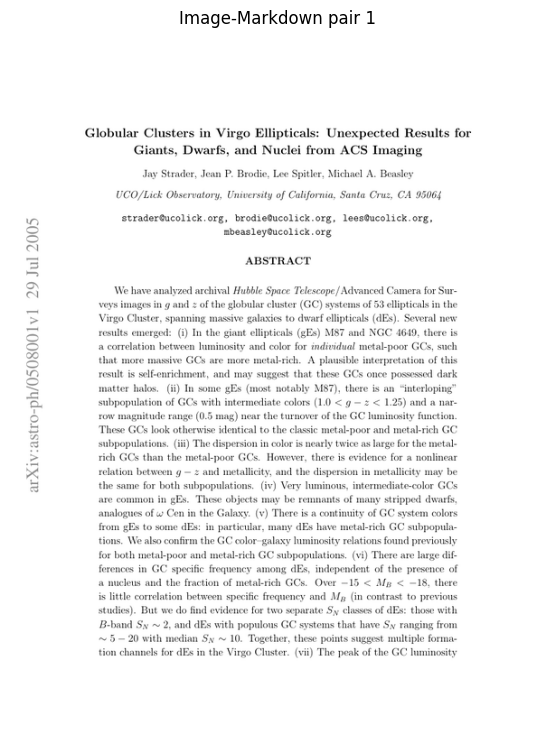

**Ground-truth Markdown preview:**

```markdown
# Globular Clusters in Virgo Ellipticals: Unexpected Results for Giants, Dwarfs, and Nuclei from ACS Imaging

Jay Strader, Jean P. Brodie, Lee Spitler, Michael A. Beasley

UCO/Lick Observatory, University of California, Santa Cruz, CA 95064 strader@ucolick.org, brodie@ucolick.org, lees@ucolick.org, mbeasley@ucolick.org

###### Abstract

We have analyzed archival _Hubble Space Telescope_/Advanced Camera for Surveys images in \(g\) and \(z\) of the globular cluster (GC) systems of 53 ellipticals in the Virgo Cluster, spanning massive galaxies to dwarf ellipticals (dEs). Several new results emerged: (i) In the giant ellipticals (gEs) M87 and NGC 4649, there is a correlation between luminosity and color for _individual_ metal-poor GCs, such that more massive GCs are more metal-rich. A plausible interpretation of this result is self-enrichment, and may suggest that these GCs once possessed dark matter halos. (ii) In some gEs (most notably M87), there is an "interloping" subpopulation of GCs with intermediate colors (1.0 \(<g-z<\) 1.25) and a narrow magnitude range (0.5 mag) near the turnover of the GC luminosity function. These GCs look otherwise identical to the classic metal-poor and metal-rich GC subpopulations. (iii) The dispersion in color is nearly twice as large for the metal-rich GCs than the metal-poor GCs. However, there is evidence for a nonlinear relation between \(g-z\) and metallicity, and the dispersion in metallicity may be the same for both subpopulations. (iv) Very luminous, intermediate-color GCs are common in gEs. These objects may be remnants of many stripped dwarfs, analogues of \(\omega\) Cen in the Galaxy. (v) There is a continuity of GC system colors from gEs to some dEs: in particular, many dEs have metal-rich GC subpopulations. We also confirm the 
...
```

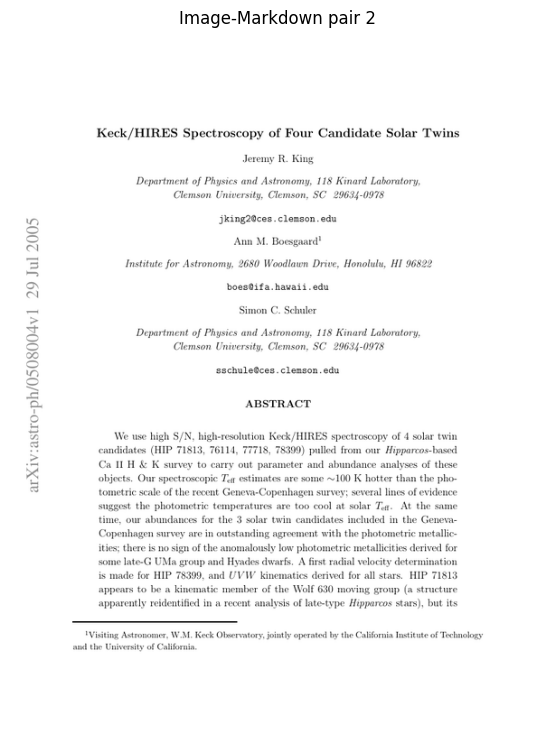

**Ground-truth Markdown preview:**

```markdown
# Keck/HIRES Spectroscopy of Four Candidate Solar Twins

Jeremy R. King

Department of Physics and Astronomy, 118 Kinard Laboratory,

Clemson University, Clemson, SC 29634-0978 jking2@ces.clemson.edu

Ann M. Boesgaard1

Footnote 1: affiliation: Visiting Astronomer, W.M. Keck Observatory, jointly operated by the California Institute of Technology and the University of California.

Institute for Astronomy, 2680 Woodlawn Drive, Honolulu, HI 96822 boes@ifa.hawaii.edu

Simon C. Schuler

Department of Physics and Astronomy, 118 Kinard Laboratory,

Clemson University, Clemson, SC 29634-0978 sschule@ces.clemson.edu

###### Abstract

We use high S/N, high-resolution Keck/HIRES spectroscopy of 4 solar twin candidates (HIP 71813, 76114, 77718, 78399) pulled from our _Hipparcos_-based Ca II H & K survey to carry out parameter and abundance analyses of these objects. Our spectroscopic \(T_{\rm eff}\) estimates are some \({\sim}100\) K hotter than the photometric scale of the recent Geneva-Copenhagen survey; several lines of evidence suggest the photometric temperatures are too cool at solar \(T_{\rm eff}\). At the same time, our abundances for the 3 solar twin candidates included in the Geneva-Copenhagen survey are in outstanding agreement with the photometric metallicities; there is no sign of the anomalously low photometric metallicities derived for some late-G UMa group and Hyades dwarfs. A first radial velocity determination is made for HIP 78399, and \(UVW\) kinematics derived for all stars. HIP 71813 appears to be a kinematic member of the Wolf 630 moving group (a structure apparently reidentified in a recent analysis of late-type _Hipparcos_ stars), but its
```

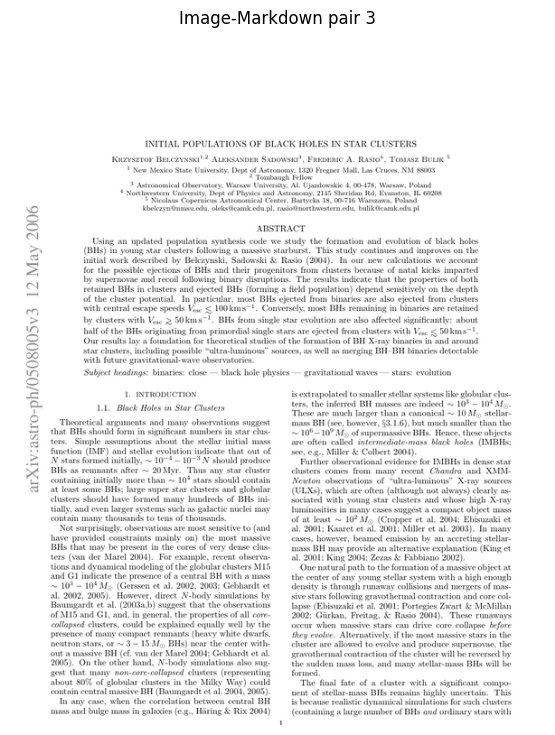

**Ground-truth Markdown preview:**

```markdown
# Initial Populations of Black Holes in Star Clusters

Krzysztof Belczynski12 Aleksander Sadowski3 , Frederic A. Rasio4 , Tomasz Bulik 5

Footnote 1: footnotetext: Statistics is much better for single stars than binaries; and even with only \(2\times 10^{5}\) single stars we obtain usually thousands, and minimum several hundred, BHs. For example see Tables 2-5

Footnote 2: The number of single BHs formed out of binary systems may be inferred by comparing the numbers of binary BHs with the single BHs listed under “binary disruption” and “binary mergers” in Tables 2–5, 7 and 8

Footnote 3: affiliationmark:

Footnote 4: affiliationmark:

Footnote 5: affiliationmark:

\({}^{1}\) New Mexico State University, Dept of Astronomy, 1320 Fregner Mall, Las Cruces, NM 88003

\({}^{2}\) Tombaugh Fellow

\({}^{3}\) Astronomical Observatory, Warsaw University, Al. Ujazdowskie 4, 00-478, Warsaw, Poland

\({}^{4}\) Northwestern University, Dept of Physics and Astronomy, 2145 Sheridan Rd, Evanston, IL 60208

\({}^{5}\) Nicolaus Copernicus Astronomical Center, Bartycka 18, 00-716 Warszawa, Poland

kbelczyn@nmsu.edu, oleks@camk.edu.pl, rasio@northwestern.edu, bulik@camk.edu.pl

###### Abstract

Using an updated population synthesis code we study the formation and evolution of black holes (BHs) in young star clusters following a massive starburst. This study continues and improves on the initial work described by Belczynski, Sadowski & Rasio (2004). In our new calculations we account for the possible ejections of BHs and their progenitors from clusters because of natal kicks imparted by supernovae and recoil following binary disruptions. The results indicate that the properties of both retained BHs in clusters and ejected BHs (forming a field population) depend sensitively on the depth of th
...
```

In [4]:
def load_document_image(path_or_image, max_side=IMAGE_MAX_SIDE):
    if isinstance(path_or_image, Image.Image):
        image = path_or_image.convert("RGB")
    else:
        image = Image.open(path_or_image).convert("RGB")
    image = ImageOps.exif_transpose(image)
    image.thumbnail((max_side, max_side), Image.Resampling.LANCZOS)
    return image


def show_pair(sample, title="Dataset sample"):
    image = load_document_image(sample["image_path"])
    plt.figure(figsize=(7, 9))
    plt.imshow(image)
    plt.axis("off")
    plt.title(title)
    plt.show()
    display(Markdown("**Ground-truth Markdown preview:**"))
    preview = sample["markdown"][:1800]
    display(Markdown("```markdown\n" + preview + ("\n..." if len(sample["markdown"]) > len(preview) else "") + "\n```"))

for idx, sample in enumerate(pairs[:3], start=1):
    show_pair(sample, title=f"Image-Markdown pair {idx}")

In [5]:
random.Random(SEED).shuffle(pairs)

if MAX_SAMPLES is not None:
    pairs = pairs[:MAX_SAMPLES]
    print(f"Using subset with MAX_SAMPLES={MAX_SAMPLES}: {len(pairs)} samples")
else:
    print(f"Using all discovered samples: {len(pairs)} samples")

val_count = max(1, int(round(len(pairs) * VAL_SIZE)))
train_samples = pairs[:-val_count]
val_samples = pairs[-val_count:]

if SMOKE_TEST:
    train_samples = train_samples[:4]
    val_samples = val_samples[:2]
    NUM_EPOCHS = 1
    print("SMOKE_TEST is enabled: using 4 train samples and 2 validation samples for a quick pipeline check.")

print(f"Train samples: {len(train_samples)}")
print(f"Validation samples: {len(val_samples)}")
print(f"Effective batch size: {PER_DEVICE_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")

Using subset with MAX_SAMPLES=120: 120 samples
Train samples: 96
Validation samples: 24
Effective batch size: 8


In [6]:
def build_prompt_messages():
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": INSTRUCTION},
            ],
        },
    ]


def build_full_messages(markdown_target: str):
    return build_prompt_messages() + [
        {"role": "assistant", "content": markdown_target}
    ]

example_messages = build_full_messages(train_samples[0]["markdown"][:500])
print("Example ChatML-style sample:")
print(example_messages)

Example ChatML-style sample:
[{'role': 'system', 'content': 'You are an expert document transcription model that converts document images into clean Markdown.'}, {'role': 'user', 'content': [{'type': 'image'}, {'type': 'text', 'text': 'Convert this document image into clean, structured Markdown. Preserve headings, equations, lists, tables, and reading order. Return only Markdown.'}]}, {'role': 'assistant', 'content': 'Given 2 or 3 data qubits we have the same equations as for 1 or 0 respectively with \\(P_{0}\\to P_{7}\\), \\(P_{a}\\to P_{b}\\), \\(P_{b}\\to P_{a}\\), and \\(P_{7}\\to P_{0}\\). That is\n\n\\[f_{b0} = f_{a7},\\] (21a) \\[f_{ba} = f_{ab},\\] (21b) \\[f_{bb} = f_{aa},\\] (21c) \\[f_{b7} = f_{a0},\\] (21d) \\[f_{70} = f_{07},\\] (21e) \\[f_{7a} = f_{0b},\\] (21f) \\[f_{7b} = f_{0a},\\] (21g) \\[f_{77} = f_{00}.\\] (21h)\n\nThis comes from the fact that the error correcting code treats \\(|000\\rangle\\) as equivalent to \\(|111\\ran'}]


In [20]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
    trust_remote_code=True,
)

if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token
processor.tokenizer.padding_side = "right"

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=COMPUTE_DTYPE,
    trust_remote_code=True,
)

model.config.use_cache = False
print("Model loaded successfully.")
print("Device map:", getattr(model, "hf_device_map", "not available"))

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Model loaded successfully.
Device map: {'model.visual.patch_embed': 0, 'model.visual.rotary_pos_emb': 0, 'model.visual.blocks.0': 0, 'model.visual.blocks.1': 0, 'model.visual.blocks.2': 0, 'model.visual.blocks.3': 0, 'model.visual.blocks.4': 0, 'model.visual.blocks.5': 0, 'model.visual.blocks.6': 0, 'model.visual.blocks.7': 0, 'model.visual.blocks.8': 0, 'model.visual.blocks.9': 0, 'model.visual.blocks.10': 0, 'model.visual.blocks.11': 0, 'model.visual.blocks.12': 0, 'model.visual.blocks.13': 0, 'model.visual.blocks.14': 0, 'model.visual.blocks.15': 0, 'model.visual.blocks.16': 0, 'model.visual.blocks.17': 0, 'model.visual.blocks.18': 0, 'model.visual.blocks.19': 0, 'model.visual.blocks.20': 0, 'model.visual.blocks.21': 1, 'model.visual.blocks.22': 1, 'model.visual.blocks.23': 1, 'model.visual.blocks.24': 1, 'model.visual.blocks.25': 1, 'model.visual.blocks.26': 1, 'model.visual.blocks.27': 1, 'model.visual.blocks.28': 1, 'model.visual.blocks.29': 1, 'model.visual.blocks.30': 1, 'model

Generating one zero-shot baseline prediction...


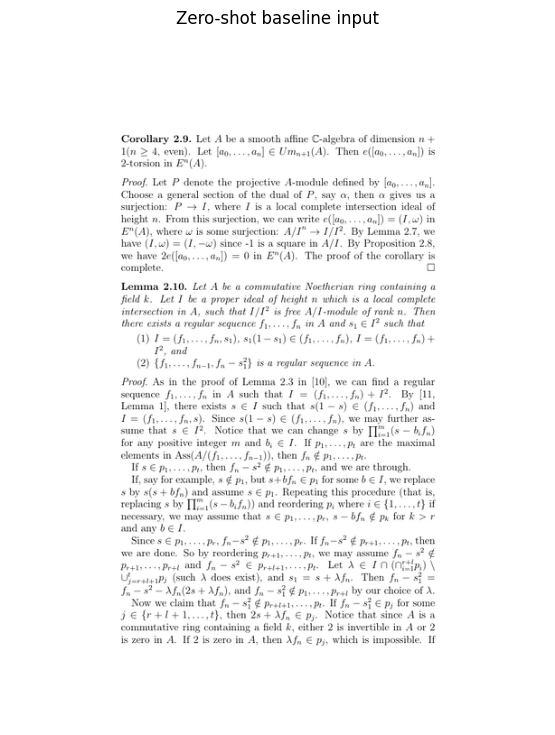

**Ground-truth Markdown preview:**

```markdown
**Corollary 2.9****.**: Let \(A\) be a smooth affine \(\mathbb{C}\)-algebra of dimension \(n+1\)(\(n\geq 4\), even). Let \([a_{0},\dots,a_{n}]\in Um_{n+1}(A)\). Then \(e([a_{0},\dots,a_{n}])\) is 2-torsion in \(E^{n}(A)\).

Proof.: Let \(P\) denote the projective \(A\)-module defined by \([a_{0},\dots,a_{n}]\). Choose a general section of the dual of \(P\), say \(\alpha\), then \(\alpha\) gives us a surjection: \(P\to I\), where \(I\) is a local complete intersection ideal of height \(n\). From this surjection, we can write \(e([a_{0},\dots,a_{n}])=(I,\omega)\) in \(E^{n}(A)\), where \(\omega\) is some surjection: \({A/I}^{n}\to I/{I^{2}}\). By Lemma 2.7, we have \((I,\omega)=(I,-\omega)\) since -1 is a square in \(A/I\). By Proposition 2.8, we have \(2e([a_{0},\dots,a_{n}])=0\) in \(E^{n}(A)\). The proof of the corollary is complete. 

**Lemma 2.10****.**: _Let \(A\) be a commutative Noetherian ring containing a field \(k\). Let \(I\) be a proper ideal of height \(n\) which is a local complete intersection in \(A\), such that \(I/{I^{2}}\) is free \(A/I\)-module of rank \(n\). Then there exists a regular sequence \(f_{1},\dots,f_{n}\) in \(A\) and \(s_{1}\in I^{2}\) such that_

1. (1)\(I=(f_{1},\dots,f_{n},s_{1})\)_,_ \(s_{1}(1-s_{1})\in(f_{1},\dots,f_{n})\)_,_ \(I=(f_{1},\dots,f_{n})+I^{2}\)_, and_
2. (2)\(\{f_{1},\dots,f_{n-1},f_{n}-s_{1}^{2}\}\) _is a regular sequence in_ \(A\)_._

Proof.: As in the proof of Lemma 2.3 in [References], we can find a regular sequence \(f_{1},\dots,f_{n}\) in \(A\) such that \(I=(f_{1},\dots,f_{n})+I^{2}\). By [References, Lemma 1], there exists \(s\in I\) such that \(s(1-s)\in(f_{1},\dots,f_{n})\) and \(I=(f_{1},\dots,f_{n},s)\). Since \(s(1-s)\in(f_{1},\dots,f_{n})\), we may further assume that \(s\in I^{2}\). Notice that we can chan
...
```

**Zero-shot generated Markdown:**

```markdown
\begin{corollary} 2.9. Let \(A\) be a smooth affine \(\mathbb{C}\)-algebra of dimension \(n+1(n \geq 4\), even). Let \([a_0, \dots, a_n] \in U_{m+1}(A)\). Then \(e([a_0, \dots, a_n])\) is 2-torsion in \(E^n(A)\). \end{corollary} \begin{proof} Let \(P\) denote the projective \(A\)-module defined by \([a_0, \dots, a_n]\). Choose a general section of the dual of \(P\), say \(\alpha\), then \(\alpha\) gives us a surjection: \(P \to I\), where \(I\) is a local complete intersection ideal of height \(n\). From this surjection, we can write \(e([a_0, \dots, a_n]) = (I, \omega)\) in \(E^n(A)\), where \(\omega\) is some surjection: \(A/I^n \to I/I^2\). By Lemma 2.7, we
```

In [8]:
def model_input_device(model):
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    return torch.device("cpu")


def build_inference_messages(image):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": INSTRUCTION},
            ],
        },
    ]


def generate_markdown(model, processor, image_or_path, max_new_tokens=MAX_NEW_TOKENS):
    model.eval()
    image = load_document_image(image_or_path)
    messages = build_inference_messages(image)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], padding=True, return_tensors="pt")
    inputs = inputs.to(model_input_device(model))

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
    return processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

if RUN_ZERO_SHOT_BASELINE:
    baseline_sample = val_samples[0]
    print("Generating one zero-shot baseline prediction...")
    zero_shot_prediction = generate_markdown(model, processor, baseline_sample["image_path"], max_new_tokens=256)
    show_pair(baseline_sample, title="Zero-shot baseline input")
    display(Markdown("**Zero-shot generated Markdown:**"))
    display(Markdown("```markdown\n" + zero_shot_prediction[:1800] + "\n```"))
else:
    zero_shot_prediction = None
    print("Zero-shot baseline skipped.")

In [9]:
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 9,232,384 || all params: 2,218,217,984 || trainable%: 0.4162


In [10]:
class NougatMarkdownDataset(torch.utils.data.Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


class Qwen2VLCollator:
    def __init__(self, processor, max_length=MAX_SEQUENCE_LENGTH):
        self.processor = processor
        self.max_length = max_length

    def __call__(self, features):
        images = []
        full_texts = []
        prompt_texts = []

        for feature in features:
            image = load_document_image(feature["image_path"])
            images.append(image)

            prompt_messages = build_prompt_messages()
            full_messages = build_full_messages(feature["markdown"])

            prompt_text = self.processor.apply_chat_template(
                prompt_messages,
                tokenize=False,
                add_generation_prompt=True,
            )
            full_text = self.processor.apply_chat_template(
                full_messages,
                tokenize=False,
                add_generation_prompt=False,
            )

            prompt_texts.append(prompt_text)
            full_texts.append(full_text)

        batch = self.processor(
            text=full_texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

        prompt_tokens = self.processor.tokenizer(
            prompt_texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
            add_special_tokens=False,
        )

        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100

        prompt_lengths = prompt_tokens["attention_mask"].sum(dim=1).tolist()
        for row_idx, prompt_len in enumerate(prompt_lengths):
            labels[row_idx, : int(prompt_len)] = -100

        fully_masked = (labels != -100).sum(dim=1) == 0
        if fully_masked.any():
            labels[fully_masked, -1] = batch["input_ids"][fully_masked, -1]

        batch["labels"] = labels
        return batch

train_dataset = NougatMarkdownDataset(train_samples)
val_dataset = NougatMarkdownDataset(val_samples)
data_collator = Qwen2VLCollator(processor)

debug_batch = data_collator([train_dataset[0]])
print({key: tuple(value.shape) for key, value in debug_batch.items() if hasattr(value, "shape")})
print("Trainable label tokens in debug batch:", int((debug_batch["labels"] != -100).sum().item()))

{'input_ids': (1, 1382), 'attention_mask': (1, 1382), 'mm_token_type_ids': (1, 1382), 'pixel_values': (2268, 1176), 'image_grid_thw': (1, 3), 'labels': (1, 1382)}
Trainable label tokens in debug batch: 1324


In [11]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

training_kwargs = dict(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1 if SMOKE_TEST else 5,
    save_steps=25 if SMOKE_TEST else 50,
    eval_steps=10 if SMOKE_TEST else 25,
    save_total_limit=2,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    max_grad_norm=0.3,
    remove_unused_columns=False,
    dataloader_num_workers=0,
    report_to="none",
)

if COMPUTE_DTYPE == torch.bfloat16:
    training_kwargs["bf16"] = True
else:
    training_kwargs["fp16"] = torch.cuda.is_available()

signature = inspect.signature(TrainingArguments.__init__).parameters
if "eval_strategy" in signature:
    training_kwargs["eval_strategy"] = "steps"
else:
    training_kwargs["evaluation_strategy"] = "steps"

training_args = TrainingArguments(**training_kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

if RUN_TRAINING:
    train_result = trainer.train()
    print(train_result)
    eval_result = trainer.evaluate()
    print("Evaluation:", eval_result)
    trainer.save_model(str(OUTPUT_DIR))
    processor.save_pretrained(str(OUTPUT_DIR))
    print(f"Saved LoRA adapter and processor to: {OUTPUT_DIR}")
else:
    print("RUN_TRAINING=False, training skipped.")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
24,3.747207,3.678840


TrainOutput(global_step=24, training_loss=5.061101357142131, metrics={'train_runtime': 774.4915, 'train_samples_per_second': 0.248, 'train_steps_per_second': 0.031, 'total_flos': 3185532173451264.0, 'train_loss': 5.061101357142131, 'epoch': 2.0})


Training Loss,Validation Loss,Step
3.747207,3.678840,24


Evaluation: {'eval_loss': 3.678839921951294}
Saved LoRA adapter and processor to: /kaggle/working/qwen2-vl-nougat-markdown-qlora


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,8.370843,4.713862,0.000192,0.416667,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.291905,3.748610,0.000146,0.833333,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.014597,0.984732,0.000080,1.250000,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.747207,0.768852,0.000022,1.666667,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,2.000000,24,3.67884,29.2352,0.821,0.821,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,2.000000,24,NaN,NaN,NaN,NaN,774.4915,0.248,0.031,3.185532e+15,5.061101
6,NaN,NaN,NaN,2.000000,24,3.67884,29.3283,0.818,0.818,NaN,NaN,NaN,NaN,NaN


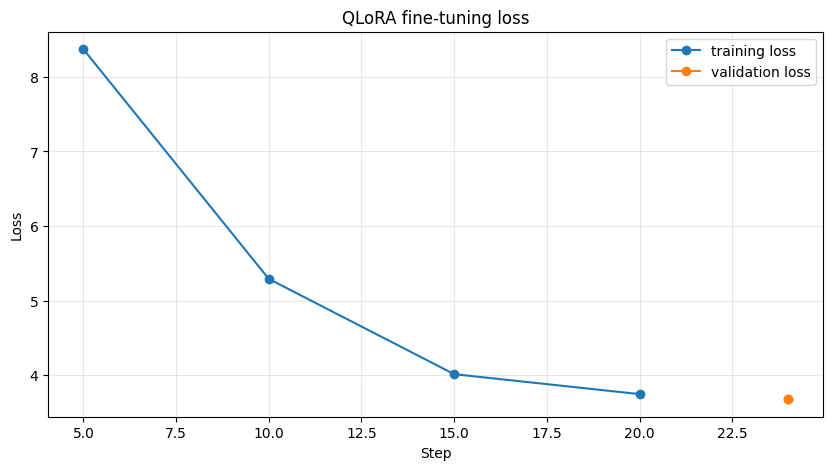

In [12]:
log_history = getattr(trainer.state, "log_history", []) if "trainer" in globals() else []
logs_df = pd.DataFrame(log_history)
display(logs_df.tail(20))

if not logs_df.empty:
    plt.figure(figsize=(10, 5))
    if "loss" in logs_df:
        train_loss_df = logs_df.dropna(subset=["loss"])
        plt.plot(train_loss_df["step"], train_loss_df["loss"], marker="o", label="training loss")
    if "eval_loss" in logs_df:
        eval_loss_df = logs_df.dropna(subset=["eval_loss"])
        plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], marker="o", label="validation loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("QLoRA fine-tuning loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("No trainer logs available yet.")

In [13]:
def make_prediction_table(samples, split_name="validation", count=3, max_new_tokens=MAX_NEW_TOKENS):
    selected = samples[: min(count, len(samples))]
    rows = []
    for idx, sample in enumerate(selected, start=1):
        print(f"Generating {split_name} prediction {idx}/{len(selected)}...")
        prediction = generate_markdown(model, processor, sample["image_path"], max_new_tokens=max_new_tokens)
        rows.append({
            "split": split_name,
            "id": sample["id"],
            "image_path": sample["image_path"],
            "ground_truth": sample["markdown"],
            "prediction": prediction,
        })
    return pd.DataFrame(rows)

validation_predictions_df = make_prediction_table(val_samples, split_name="validation", count=3)
display(validation_predictions_df[["split", "id", "image_path"]])

Generating validation prediction 1/3...
Generating validation prediction 2/3...
Generating validation prediction 3/3...


,split,id,image_path
0,validation,06,/kaggle/input/datasets/zphilip/nougat-training...
1,validation,06,/kaggle/input/datasets/zphilip/nougat-training...
2,validation,03,/kaggle/input/datasets/zphilip/nougat-training...


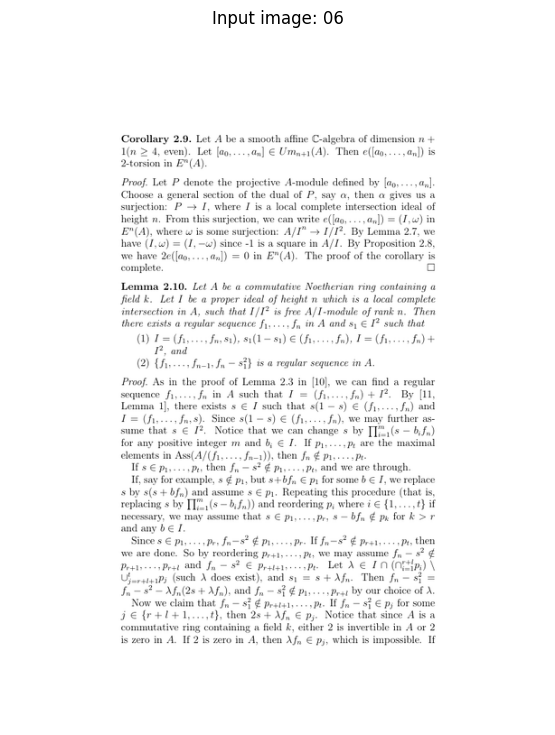

### Ground Truth Markdown

```markdown
**Corollary 2.9****.**: Let \(A\) be a smooth affine \(\mathbb{C}\)-algebra of dimension \(n+1\)(\(n\geq 4\), even). Let \([a_{0},\dots,a_{n}]\in Um_{n+1}(A)\). Then \(e([a_{0},\dots,a_{n}])\) is 2-torsion in \(E^{n}(A)\).

Proof.: Let \(P\) denote the projective \(A\)-module defined by \([a_{0},\dots,a_{n}]\). Choose a general section of the dual of \(P\), say \(\alpha\), then \(\alpha\) gives us a surjection: \(P\to I\), where \(I\) is a local complete intersection ideal of height \(n\). From this surjection, we can write \(e([a_{0},\dots,a_{n}])=(I,\omega)\) in \(E^{n}(A)\), where \(\omega\) is some surjection: \({A/I}^{n}\to I/{I^{2}}\). By Lemma 2.7, we have \((I,\omega)=(I,-\omega)\) since -1 is a square in \(A/I\). By Proposition 2.8, we have \(2e([a_{0},\dots,a_{n}])=0\) in \(E^{n}(A)\). The proof of the corollary is complete. 

**Lemma 2.10****.**: _Let \(A\) be a commutative Noetherian ring containing a field \(k\). Let \(I\) be a proper ideal of height \(n\) which is a local complete intersection in \(A\), such that \(I/{I^{2}}\) is free \(A/I\)-module of rank \(n\). Then there exists a regular sequence \(f_{1},\dots,f_{n}\) in \(A\) and \(s_{1}\in I^{2}\) such that_

1. (1)\(I=(f_{1},\dots,f_{n},s_{1})\)_,_ \(s_{1}(1-s_{1})\in(f_{1},\dots,f_{n})\)_,_ \(I=(f_{1},\dots,f_{n})+I^{2}\)_, and_
2. (2)\(\{f_{1},\dots,f_{n-1},f_{n}-s_{1}^{2}\}\) _is a regular sequence in_ \(A\)_._

Proof.: As in the proof of Lemma 2.3 in [References], we can find a regular sequence \(f_{1},\dots,f_{n}\) in \(A\) such that \(I=(f_{1},\dots,f_{n})+I^{2}\). By [References, Lemma 1], there exists \(s\in I\) such that \(s(1-s)\in(f_{1},\dots,f_{n})\) and \(I=(f_{1},\dots,f_{n},s)\). Since \(s(1-s)\in(f_{1},\dots,f_{n})\), we may further assume that \(s\in I^{2}\). Notice that we can change \(s\) by \(\prod_{i=1}^{m}(s-b_{i}f_{n})\) for any positive integer \(m\) and \(b_{i}\in I\). If \(p_{1},\dots,p_{t}\) are the maximal elements in Ass\((A/{(f_{1},\dots,f_{n-1})})\), then \(f_{n}\notin p_{1},\dots,p_{t}\).

If \(s\in p_{1},\dots,p_{t}\), then \(f_{n}-s^{2}\notin p_{1},\dots,p_{t}\), and we are through.

If, say for example, \(s\notin p_{1}\), but \(s+bf_{n}\in p_{1}\) for some \(b\in I\), we replace \(s\) by \(s(s+bf_{n})\) and assume \(s\in p_{1}\). Repeating this procedure (that is, replacing \(s\) by \(\prod_{i=1}^{m}(s-b_{i}f_{n})\)) and reordering \(p_{i}\) where \(i\in\{1,\dots,t\}\) if necessary, we may assume that \(s\in p_{1},\dots,p_{r}\), \(s-bf_{n}\notin p_{k}
```

### Generated Markdown

```markdown
Corollary 2.9. Let \(A\) be a smooth affine \(\mathbb{C}\)-algebra of dimension \(n+1(n\geq4\), even). Let \([a_{0},\dots,a_{n}]\in U_{m+n}(A).\) Then \(e([a_{0},\dots,a_{n}])\) is 2-torsion in \(E^{n}(A)\).

Proof. Let \(P\) denote the projective \(A\)-module defined by \([a_{0},\dots,a_{n}].\) Choose a general section of the dual of \(P,\) say \(\alpha,\) then \(\alpha\) gives us a surjection: \(P\rightarrow I,\) where \(I\) is a local complete intersection ideal of height \(n.\) From this surjection, we can write \(e([a_{0},\dots,a_{n}])=I/\omega\) in \(E^{n}(A),\) where \(\omega\) is some surjection: \(A/I'\rightarrow I/I'.\) By Lemma 2.7, we have \((I,\omega)=(I,-\omega)\) since -1 is a square in \(A/I.\) By Proposition 2.8, we have \(2e([a_{0},\dots,a_{n}])=0\) in \(E^{n}(A).\)
The proof of the corollary is complete.
\end{proof}

\begin{lemma}
Let \(A\) be a commutative Noetherian ring containing a field \(k.\) Let \(I\) be a proper ideal of height \(n\) which is a local complete intersection in \(A,\) such that \(I/I'\) is free \(A/I\)-module of rank \(n.\) Then there exists a regular sequence \(f_{1},\dots,f_{n}\) in \(A\) and \(s_{i}\in I^{2}\) such that
\begin{enumerate}
\item \(I=(f_{1},\dots,f_{n},s_{1}),\ s_{1}(1-s_{1})\in(f_{1},\dots,f_{n}),\ I=(f_{1},\dots,f_{n})+I^{2},\) and
\item \(\{f_{1},\dots,f_{n-1},f_{n}-
```

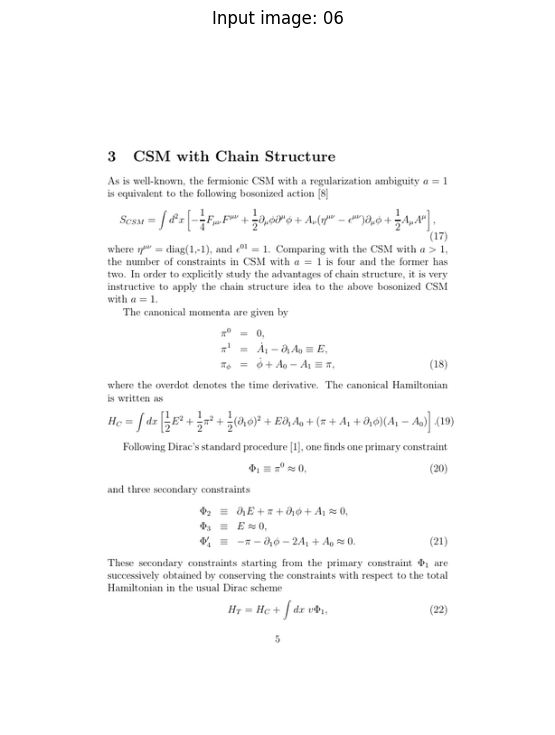

### Ground Truth Markdown

```markdown
CSM with Chain Structure

As is well-known, the fermionic CSM with a regularization ambiguity \(a=1\) is equivalent to the following bosonized action [8]

\[S_{CSM}=\int d^{2}x\left[-\frac{1}{4}F_{\mu\nu}F^{\mu\nu}+\frac{1}{2}\partial_ {\mu}\phi\partial^{\mu}\phi+A_{\nu}(\eta^{\mu\nu}-\epsilon^{\mu\nu})\partial_{ \mu}\phi+\frac{1}{2}A_{\mu}A^{\mu}\right],\] (17)

where \(\eta^{\mu\nu}=\mbox{diag(1,-1)}\), and \(\epsilon^{01}=1\). Comparing with the CSM with \(a>1\), the number of constraints in CSM with \(a=1\) is four and the former has two. In order to explicitly study the advantages of chain structure, it is very instructive to apply the chain structure idea to the above bosonized CSM with \(a=1\).

The canonical momenta are given by

\[\pi^{0} = 0,\] \[\pi^{1} = \dot{A}_{1}-\partial_{1}A_{0}\equiv E,\] \[\pi_{\phi} = \dot{\phi}+A_{0}-A_{1}\equiv\pi,\] (18)

where the overdot denotes the time derivative. The canonical Hamiltonian is written as

\[H_{C}=\int dx\left[\frac{1}{2}E^{2}+\frac{1}{2}\pi^{2}+\frac{1}{ 2}(\partial_{1}\phi)^{2}+E\partial_{1}A_{0}+(\pi+A_{1}+\partial_{1}\phi)(A_{1} -A_{0})\right].\] (19)

Following Dirac's standard procedure [1], one finds one primary constraint

\[\Phi_{1}\equiv\pi^{0}\approx 0,\] (20)

and three secondary constraints

\[\Phi_{2} \equiv \partial_{1}E+\pi+\partial_{1}\phi+A_{1}\approx 0,\] \[\Phi_{3} \equiv E\approx 0,\] \[\Phi^{\prime}_{4} \equiv -\pi-\partial_{1}\phi-2A_{1}+A_{0}\approx 0.\] (21)

These secondary constraints starting from the primary constraint \(\Phi_{1}\) are successively obtained by conserving the constraints with respect to the total Hamiltonian in the usual Dirac scheme

\[H_{T}=H_{C}+\int dx~{}v\Phi_{1},\] (22)
```

### Generated Markdown

```markdown
\section*{3 CSM with Chain Structure}

As is well-known, the fermionic CSM with a regularization ambiguity \(a=1\) is equivalent to the following bosonized action \cite{BosonizationAction}

\[ S_{CSM} = \int d^{3}x \left[ -\frac{1}{4}F_{\mu \nu }F^{\mu \nu } + \frac{1}{2}\partial _{\mu }\phi \partial ^{\mu }\phi + A_{\nu }(\eta ^{\mu \nu }-\epsilon ^{\mu \nu })\partial _{\mu }\phi + \frac{1}{2}A_{\nu }A^{\nu } \right] , \]

where \(\eta ^{\mu \nu }=\mathrm{diag}(1,-1)\), and \(\epsilon ^{01}=1\). Comparing with the CSM with \(a>1\), the number of constraints in CSM with \(a=1\) is four and the former has two. In order to explicitly study the advantages of chain structure, it is very instructive to apply the chain structure idea to the above bosonized CSM with \(a=1\).

The canonical momenta are given by

\begin{equation}
\begin{array}{ll}
\pi ^{0} & = 0, \\
\pi ^{1} & = \hat{A}_{1}-\partial _{t}A_{0}\equiv E, \\
\pi _{\phi } & = \hat{\phi }+A_{0}-A_{1}\equiv \pi ,
\end{array}
\end{equation}

where the overdot denotes the time derivative. The canonical Hamiltonian is written as

\[ H_{C} = \int dx \left[ \frac{1}{2}E^{2}+\frac{1}{2}\pi ^{2}+\frac{1}{2}(\partial _{t}\phi )^{2}+E\partial _{t}A_{0}+(\pi +A_{1}+\partial _{t}\phi )(A_{1}-A_{0}) \right] . \]

Following Dirac's standard procedure \cite{Dirac}, one finds one primary constraint

\begin{equation}
\Phi _{1}\equiv \pi ^{0}\approx
```

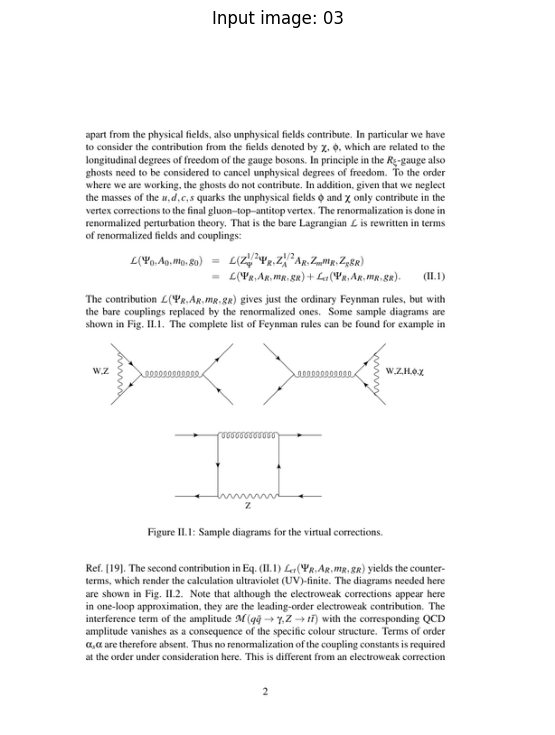

### Ground Truth Markdown

```markdown
apart from the physical fields, also unphysical fields contribute. In particular we have to consider the contribution from the fields denoted by \(\chi\), \(\phi\), which are related to the longitudinal degrees of freedom of the gauge bosons. In principle in the \(R_{\xi}\)-gauge also ghosts need to be considered to cancel unphysical degrees of freedom. To the order where we are working, the ghosts do not contribute. In addition, given that we neglect the masses of the \(u,d,c,s\) quarks the unphysical fields \(\phi\) and \(\chi\) only contribute in the vertex corrections to the final gluon-top-antitop vertex. The renormalization is done in renormalized perturbation theory. That is the bare Lagrangian \(\cal L\) is rewritten in terms of renormalized fields and couplings:

\[{\cal L}(\Psi_{0},A_{0},m_{0},g_{0}) = {\cal L}(Z^{1/2}_{\Psi}\Psi_{R},Z^{1/2}_{A}A_{R},Z_{m}m_{R},Z_{g} g_{R})\] (II.1) \[= {\cal L}(\Psi_{R},A_{R},m_{R},g_{R})+{\cal L}_{ct}(\Psi_{R},A_{R} ,m_{R},g_{R}).\]

The contribution \({\cal L}(\Psi_{R},A_{R},m_{R},g_{R})\) gives just the ordinary Feynman rules, but with the bare couplings replaced by the renormalized ones. Some sample diagrams are shown in Fig. II.1.



The complete list of Feynman rules can be found for example in Ref. [19]. The second contribution in Eq. (II.1) \({\cal L}_{ct}(\Psi_{R},A_{R},m_{R},g_{R})\) yields the counterterms, which render the calculation ultraviolet (UV)-finite. The diagrams needed here are shown in Fig. II.2. Note that although the electroweak corrections appear here in one-loop approximation, they are the leading-order electroweak contribution.



The interference term of the amplitude \({\cal M}(q\bar{q}\to\gamma,Z\to t\bar{t})\) with the corresponding QCD amplitude vanishes as a consequence of the specific colour structure. Terms of order \(\alpha_{s}\alpha\) are therefore absent. Thus no renormalization of the coupling constants is required at the order under consideration here. This is different from an electroweak correction

Figure II.1: Sample diagrams for the virtual corrections.
```

### Generated Markdown

```markdown
apart from the physical fields, also unphysical fields contribute. In particular we have to consider the contribution from the fields denoted by \(\chi\), \(\phi\), which are related to the longitudinal degrees of freedom of the gauge bosons. In principle in the \(R_{\mathrm{g}}\)-gauge also ghosts need to be considered to cancel unphysical degrees of freedom. To the order where we are working, the ghosts do not contribute. In addition, given that we neglect the masses of the \(u,d,c,s\) quarks the unphysical fields \(\phi\) and \(\chi\) only contribute in the vertex corrections to the final gluon-top-antitop vertex. The renormalization is done in renormalized perturbation theory. That is the bare Lagrangian \(\mathcal{L}\) is rewritten in terms of renormalized fields and couplings:
\begin{equation}
\begin{array}{ll}
\mathcal{L}(\Psi_{\mathrm{D}},A_{\mathrm{D}},m_{\mathrm{D}},g_{\mathrm{D}}) & = & \mathcal{L}(Z_{\mathrm{Q}}^{1/2}\Psi_{\mathrm{R}},Z_{\mathrm{A}}^{1/2}A_{\mathrm{R}},Z_{\mathrm{m}}m_{\mathrm{R}},Z_{\mathrm{g}}g_{\mathrm{R}}) \\
& = & \mathcal{L}(\Psi_{\mathrm{R}},A_{\mathrm{R}},m_{\mathrm{R}},g_{\mathrm{R}})+\mathcal{L}_{\mathrm{ct}}(\Psi_{\mathrm{R}},A_{\mathrm{R}},m_{\mathrm{R}},g_{\mathrm{R}}).
\end{array}
\end{equation}
The contribution \(\mathcal{L}(\Psi_{\mathrm{R}},A_{\mathrm{R}},m_{\mathrm{R}},g_{\mathrm{R}})\) gives just the ordinary Feynman rules, but with the bare couplings replaced by the renormalized ones. Some sample diagrams are shown in Fig. II.1. The complete list of Feynman rules can be found for example in
\begin{center}
\includegraphics[width=0.8\textwidth
```

In [14]:
def visualize_prediction(row):
    image = load_document_image(row["image_path"])
    plt.figure(figsize=(7, 9))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Input image: {row['id']}")
    plt.show()

    display(Markdown("### Ground Truth Markdown"))
    display(Markdown("```markdown\n" + str(row["ground_truth"])[:2500] + "\n```"))
    display(Markdown("### Generated Markdown"))
    display(Markdown("```markdown\n" + str(row["prediction"])[:2500] + "\n```"))

for _, row in validation_predictions_df.iterrows():
    visualize_prediction(row)

Generating train prediction 1/3...
Generating train prediction 2/3...
Generating train prediction 3/3...
No separate unseen image dataset found. Falling back to 3 validation images as unseen-style tests.
Generating unseen_fallback_validation prediction 1/3...
Generating unseen_fallback_validation prediction 2/3...
Generating unseen_fallback_validation prediction 3/3...


,split,id,image_path
0,train,12,/kaggle/input/datasets/zphilip/nougat-training...
1,train,01,/kaggle/input/datasets/zphilip/nougat-training...
2,train,10,/kaggle/input/datasets/zphilip/nougat-training...
3,unseen_fallback_validation,02,/kaggle/input/datasets/zphilip/nougat-training...
4,unseen_fallback_validation,04,/kaggle/input/datasets/zphilip/nougat-training...
5,unseen_fallback_validation,03,/kaggle/input/datasets/zphilip/nougat-training...


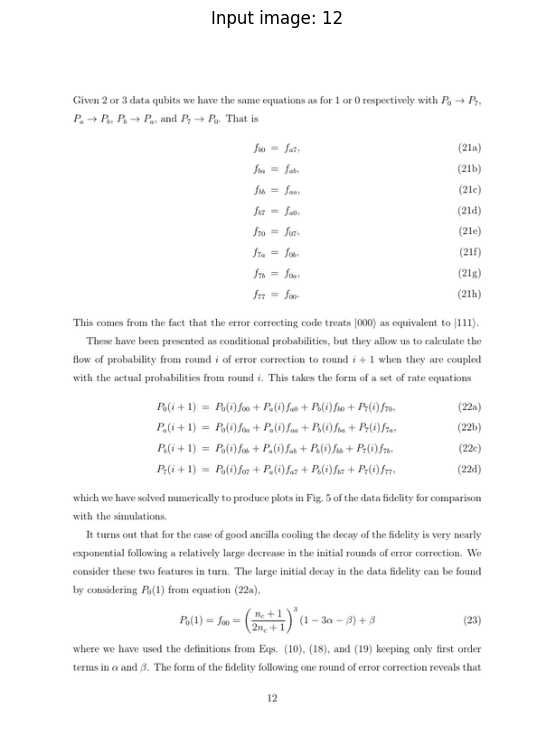

### Ground Truth Markdown

```markdown
Given 2 or 3 data qubits we have the same equations as for 1 or 0 respectively with \(P_{0}\to P_{7}\), \(P_{a}\to P_{b}\), \(P_{b}\to P_{a}\), and \(P_{7}\to P_{0}\). That is

\[f_{b0} = f_{a7},\] (21a) \[f_{ba} = f_{ab},\] (21b) \[f_{bb} = f_{aa},\] (21c) \[f_{b7} = f_{a0},\] (21d) \[f_{70} = f_{07},\] (21e) \[f_{7a} = f_{0b},\] (21f) \[f_{7b} = f_{0a},\] (21g) \[f_{77} = f_{00}.\] (21h)

This comes from the fact that the error correcting code treats \(|000\rangle\) as equivalent to \(|111\rangle\).

These have been presented as conditional probabilities, but they allow us to calculate the flow of probability from round \(i\) of error correction to round \(i+1\) when they are coupled with the actual probabilities from round \(i\). This takes the form of a set of rate equations

\[P_{0}(i+1) = P_{0}(i)f_{00}+P_{a}(i)f_{a0}+P_{b}(i)f_{b0}+P_{7}(i)f_{70},\] (22a) \[P_{a}(i+1) = P_{0}(i)f_{0a}+P_{a}(i)f_{aa}+P_{b}(i)f_{ba}+P_{7}(i)f_{7a},\] (22b) \[P_{b}(i+1) = P_{0}(i)f_{0b}+P_{a}(i)f_{ab}+P_{b}(i)f_{bb}+P_{7}(i)f_{7b},\] (22c) \[P_{7}(i+1) = P_{0}(i)f_{07}+P_{a}(i)f_{a7}+P_{b}(i)f_{b7}+P_{7}(i)f_{77},\] (22d)

which we have solved numerically to produce plots in Fig. 5 of the data fidelity for comparison with the simulations.



It turns out that for the case of good ancilla cooling the decay of the fidelity is very nearly exponential following a relatively large decrease in the initial rounds of error correction. We consider these two features in turn. The large initial decay in the data fidelity can be found by considering \(P_{0}(1)\) from equation (22a),

\[P_{0}(1)=f_{00}=\left(\frac{n_{c}+1}{2n_{c}+1}\right)^{3}\left(1-3\alpha-\beta \right)+\beta\] (23)

where we have used the definitions from Eqs. (10), (18), and (19) keeping only first order terms in \(\alpha\) and \(\beta\). The form of the fidelity following one round of error correction reveals that
```

### Generated Markdown

```markdown
Given 2 or 3 data qubits we have the same equations as for 1 or 0 respectively with \(P_{0} \rightarrow P_{7}\), \(P_{a} \rightarrow P_{b}\), \(P_{b} \rightarrow P_{a}\), and \(P_{7} \rightarrow P_{0}\). That is

\[ f_{00} \ = \ f_{a7}, \]

\[ f_{ba} \ = \ f_{ab}, \]

\[ f_{bb} \ = \ f_{aa}, \]

\[ f_{07} \ = \ f_{a0}, \]

\[ f_{70} \ = \ f_{07}, \]

\[ f_{7a} \ = \ f_{06}, \]

\[ f_{7b} \ = \ f_{0a}, \]

\[ f_{77} \ = \ f_{00}. \]

This comes from the fact that the error correcting code treats [000] as equivalent to [111].

These have been presented as conditional probabilities, but they allow us to calculate the flow of probability from round \(i\) of error correction to round \(i+1\) when they are coupled with the actual probabilities from round \(i\). This takes the form of a set of rate equations

\[ P_{0}(i+1) \ = \ P_{0}(i)f_{00} + P_{a}(i)f_{0a} + P_{b}(i)f_{0b} + P_{7}(i)f_{70}, \]

\[ P_{a}(i+1) \ = \ P_{0}(i)f_{0a} + P_{a}(i)f_{aa} + P_{b}(i)f_{ba} + P_{7}(i)f_{7a}, \]

\[ P_{b}(i+1) \ = \ P_{0}(i)f_{0b} + P_{a}(i)f_{ab} + P_{b}(i)f_{ba} + P_{7}(i)f_{7b}, \]

\[ P_{7}(i+1) \ = \ P_{0}(i)f_{07} + P_{a}(i)f_{aa} + P_{b}(i)f_{ab} + P_{7}(i)f_{77}, \]

which we have solved numerically to produce plots
```

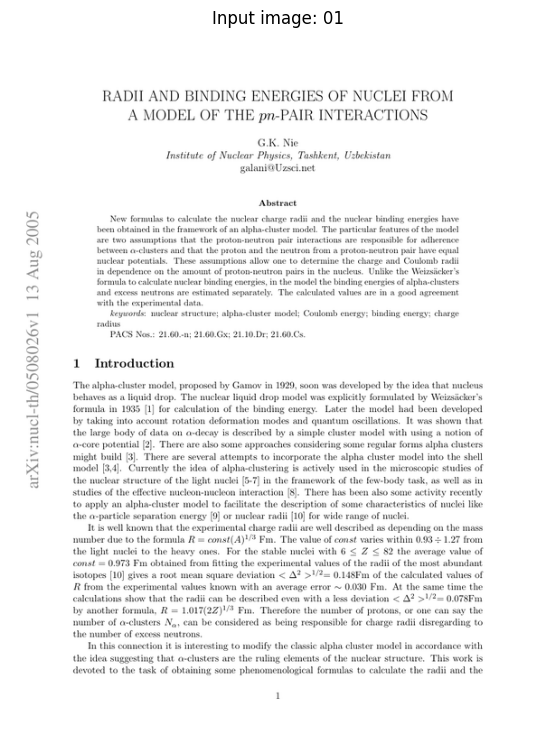

### Ground Truth Markdown

```markdown
# RADII AND BINDING ENERGIES OF NUCLEI FROM

A MODEL OF THE \(pn\)-PAIR INTERACTIONS

 G.K. Nie

_Institute of Nuclear Physics, Tashkent, Uzbekistan_

galani@Uzsci.net

###### Abstract

New formulas to calculate the nuclear charge radii and the nuclear binding energies have been obtained in the framework of an alpha-cluster model. The particular features of the model are two assumptions that the proton-neutron pair interactions are responsible for adherence between \(\alpha\)-clusters and that the proton and the neutron from a proton-neutron pair have equal nuclear potentials. These assumptions allow one to determine the charge and Coulomb radii in dependence on the amount of proton-neutron pairs in the nucleus. Unlike the Weizsacker's formula to calculate nuclear binding energies, in the model the binding energies of alpha-clusters and excess neutrons are estimated separately. The calculated values are in a good agreement with the experimental data.

_keywords_: nuclear structure; alpha-cluster model; Coulomb energy; binding energy; charge radius

PACS Nos.: 21.60.-n; 21.60.Gx; 21.10.Dr; 21.60.Cs.

## 1 Introduction

The alpha-cluster model, proposed by Gamov in 1929, soon was developed by the idea that nucleus behaves as a liquid drop. The nuclear liquid drop model was explicitly formulated by Weizsacker's formula in 1935 [1] for calculation of the binding energy. Later the model had been developed by taking into account rotation deformation modes and quantum oscillations. It was shown that the large body of data on \(\alpha\)-decay is described by a simple cluster model with using a notion of \(\alpha\)-core potential [2]. There are also some approaches considering some regular forms alpha clusters might build [3]. There are several attempts to incorporate the alpha cluster model into the shell model [3,4]. Currently the idea of alpha-clustering is actively used in the microscopic studies of the nuclear structure of the light nuclei [5-7] in the framework of the few-body task, as well as in studies of the effective nucleon-nucleon interaction [8]. There has been also some activity recently to apply an alpha-cluster model to facilitate the description of some characteristics of nuclei like the \(\alpha\)-particle separation energy [9] or nuclear radii [10] for wide range of nuclei.

It is well known that the experimental charge radii are well described as depending on the mass number due to the formula \(R=const(A)^{1/3}\) Fm. The value of \(const\) vari
```

### Generated Markdown

```markdown
\section*{Radii and Binding Energies of Nuclei from a Model of the pn-Pair Interactions}

\subsection*{Introduction}

The alpha-cluster model, proposed by Gamov in 1929, soon was developed by the idea that nuclei behaves as a liquid drop. The nuclear liquid drop model was explicitly formulated by Weizsacker's formula in 1935 \cite{Weizsacker} for calculation of the binding energy. Later the model had been developed by taking into account rotation deformation modes and quantum oscillations. It was shown that the large body of data on alpha-decay is described by a simple cluster model with using a notion of alpha-core potential \cite{alpha-core}. There are also some approaches considering some regular forms alpha clusters might build \cite{alpha-cluster}. There are several attempts to incorporate the alpha cluster model into the shell model \cite{shell-model}, and the current idea of alpha-cluster is actively used in the microscopic studies of the nucleus structure of the light nuclei \cite{light-nuclei} in the framework of the few-body task, as well as in studies of the effective nucleon-nucleon interaction \cite{effective-interaction}. There has been also some attempts recently to apply an alpha-cluster model to facilitate the description of some characteristics of nuclei like the alpha particle separation energy \cite{alpha-particle-separation-energy} or nuclear radii \cite{radii} for wide range of nuclei.

It is well known that the experimental charge radii are well described as depending on the mass number due to the formula \( R = const(A)^{1/3} \) Fm. The value of const varies within \( 0.93 \div 1.27 \) from the light nuclei to the heavy ones. For the stable nuclei with \( 6 \leq Z \leq 82 \) the average value of const \( = 0.973 \) Fm obtained from fitting the experimental values of the radii of the most abundant isotopes \cite{radii} gives a root mean square deviation \( < \Delta^{2} >^{1/2} = 0.148 \)Fm of the calculated values of \( R \) from the experimental values known with an average error \( \sim 0.030 \) Fm. At the same time the calculations show that the radii can be described even with a less deviation
```

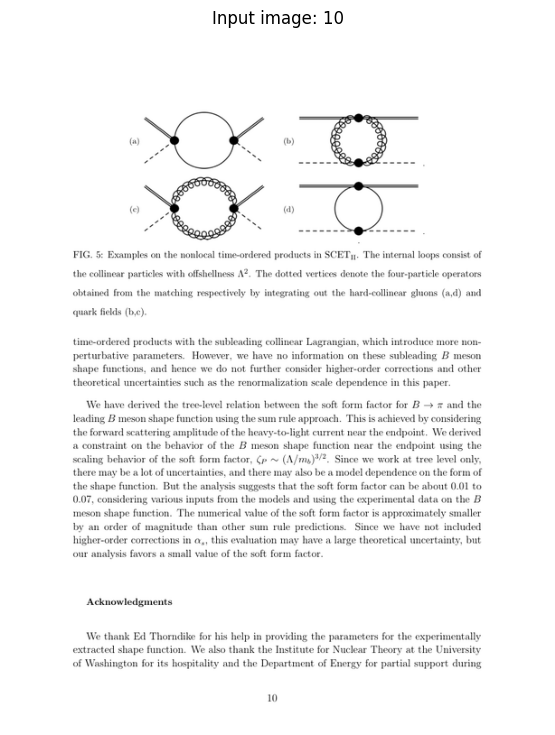

### Ground Truth Markdown

```markdown
time-ordered products with the subleading collinear Lagrangian, which introduce more nonperturbative parameters. However, we have no information on these subleading \(B\) meson shape functions, and hence we do not further consider higher-order corrections and other theoretical uncertainties such as the renormalization scale dependence in this paper.

We have derived the tree-level relation between the soft form factor for \(B\rightarrow\pi\) and the leading \(B\) meson shape function using the sum rule approach. This is achieved by considering the forward scattering amplitude of the heavy-to-light current near the endpoint. We derived a constraint on the behavior of the \(B\) meson shape function near the endpoint using the scaling behavior of the soft form factor, \(\zeta_{P}\sim(\Lambda/m_{b})^{3/2}\). Since we work at tree level only, there may be a lot of uncertainties, and there may also be a model dependence on the form of the shape function. But the analysis suggests that the soft form factor can be about 0.01 to 0.07, considering various inputs from the models and using the experimental data on the \(B\) meson shape function. The numerical value of the soft form factor is approximately smaller by an order of magnitude than other sum rule predictions. Since we have not included higher-order corrections in \(\alpha_{s}\), this evaluation may have a large theoretical uncertainty, but our analysis favors a small value of the soft form factor.

## Acknowledgments

We thank Ed Thorndike for his help in providing the parameters for the experimentally extracted shape function. We also thank the Institute for Nuclear Theory at the University of Washington for its hospitality and the Department of Energy for partial support during
```

### Generated Markdown

```markdown
(10,10),(989,987)
```

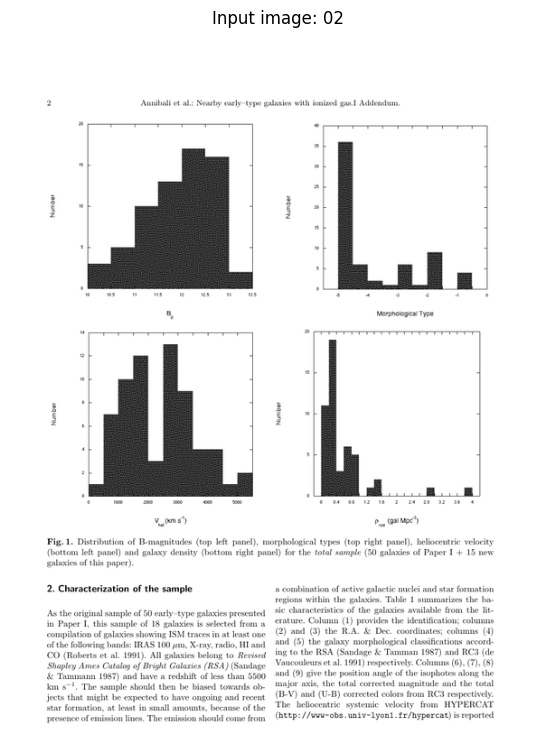

### Ground Truth Markdown

```markdown
## 2 Characterization of the sample

As the original sample of 50 early-type galaxies presented in Paper I, this sample of 18 galaxies is selected from a compilation of galaxies showing ISM traces in at least one of the following bands: IRAS 100 \(\mu\)m, X-ray, radio, HI and CO (Roberts et al. Ro91 (1991)). All galaxies belong to _Revised Shapley Ames Catalog of Bright Galaxies (RSA)_ (Sandage & Tammann RSA (1987)) and have a redshift of less than 5500 km s\({}^{-1}\). The sample should then be biased towards objects that might be expected to have ongoing and recent star formation, at least in small amounts, because of the presence of emission lines. The emission should come from a combination of active galactic nuclei and star formation regions within the galaxies. Table 1 summarizes the basic characteristics of the galaxies available from the literature. Column (1) provides the identification; columns (2) and (3) the R.A. & Dec. coordinates; columns (4) and (5) the galaxy morphological classifications according to the RSA (Sandage & Tamman RSA (1987)) and RC3 (de Vaucouleurs et al. RC3 (1991)) respectively. Columns (6), (7), (8) and (9) give the position angle of the isophotes along the major axis, the total corrected magnitude and the total (B-V) and (U-B) corrected colors from RC3 respectively. The heliocentric systemic velocity from HYPERCAT (http://www-obs.univ-lyon1.fr/hypercat) is reported

Figure 1: Distribution of B-magnitudes (top left panel), morphological types (top right panel), heliocentric velocity (bottom left panel) and galaxy density (bottom right panel) for the _total sample_ (50 galaxies of Paper I + 15 new galaxies of this paper).
```

### Generated Markdown

```markdown
(10,10),(988,988)
```

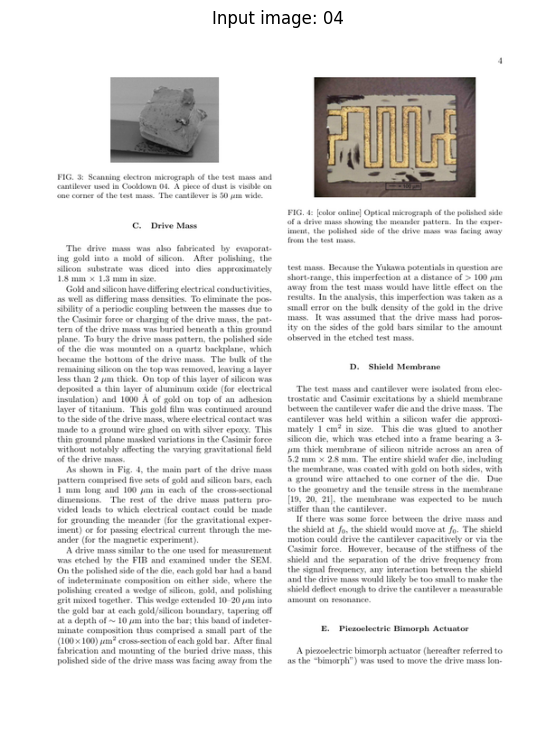

### Ground Truth Markdown

```markdown
S2.F3][ENDFIGURE]

### Drive Mass

The drive mass was also fabricated by evaporating gold into a mold of silicon. After polishing, the silicon substrate was diced into dies approximately 1.8 mm \(\times\) 1.3 mm in size.

Gold and silicon have differing electrical conductivities, as well as differing mass densities. To eliminate the possibility of a periodic coupling between the masses due to the Casimir force or charging of the drive mass, the pattern of the drive mass was buried beneath a thin ground plane. To bury the drive mass pattern, the polished side of the die was mounted on a quartz backplane, which became the bottom of the drive mass. The bulk of the remaining silicon on the top was removed, leaving a layer less than 2 \(\mu\)m thick. On top of this layer of silicon was deposited a thin layer of aluminum oxide (for electrical insulation) and 1000 A of gold on top of an adhesion layer of titanium. This gold film was continued around to the side of the drive mass, where electrical contact was made to a ground wire glued on with silver epoxy. This thin ground plane masked variations in the Casimir force without notably affecting the varying gravitational field of the drive mass.

As shown in Fig. 4, the main part of the drive mass pattern comprised five sets of gold and silicon bars, each 1 mm long and 100 \(\mu\)m in each of the cross-sectional dimensions. The rest of the drive mass pattern provided leads to which electrical contact could be made for grounding the meander (for the gravitational experiment) or for passing electrical current through the meander (for the magnetic experiment).

A drive mass similar to the one used for measurement was etched by the FIB and examined under the SEM. On the polished side of the die, each gold bar had a band of indeterminate composition on either side, where the polishing created a wedge of silicon, gold, and polishing grit mixed together. This wedge extended 10-20 \(\mu\)m into the gold bar at each gold/silicon boundary, tapering off at a depth of \(\sim 10\)\(\mu\)m into the bar; this band of indeterminate composition thus comprised a small part of the (\(100\times 100\)) \(\mu\)m\({}^{2}\) cross-section of each gold bar. After final fabrication and mounting of the buried drive mass, this polished side of the drive mass was facing away from the test mass. Because the Yukawa potentials in question are short-range, this imperfection at a distance of \(>100\)\(\mu\)m away from the test mass would have little
```

### Generated Markdown

```markdown
(10,10),(990,987)
```

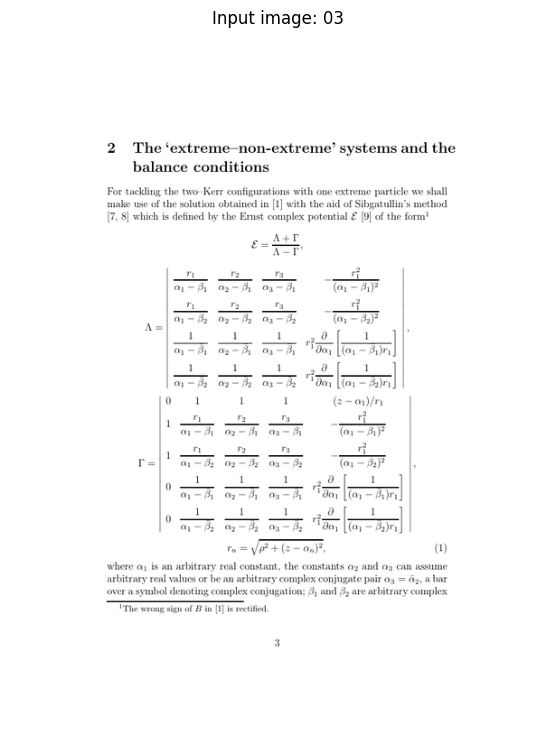

### Ground Truth Markdown

```markdown
The 'extreme-non-extreme' systems and the balance conditions

For tackling the two-Kerr configurations with one extreme particle we shall make use of the solution obtained in [1] with the aid of Sibgatullin's method [7, 8] which is defined by the Ernst complex potential \({\cal{E}}\)[9] of the form1

Footnote 1: The wrong sign of \(B\) in [1] is rectified.

\[{\cal{E}}=\frac{\Lambda+\Gamma}{\Lambda-\Gamma},\]

\[\Lambda=\left|\begin{array}[]{cccc}\frac{r_{1}}{\alpha_{1}-\beta_ {1}}&\frac{r_{2}}{\alpha_{2}-\beta_{1}}&\frac{r_{3}} {\alpha_{3}-\beta_{1}}&-\frac{r_{1}^{2}}{(\alpha_{1}-\beta_{1})^{ 2}}\\ \vspace{0.25cm}\frac{r_{1}}{\alpha_{1}-\beta_{2}}& \frac{r_{2}}{\alpha_{2}-\beta_{2}}&\frac{r_{3}}{\alpha_{3}-\beta_ {2}}&-\frac{r_{1}^{2}}{(\alpha_{1}-\beta_{2})^{2}}\\ \vspace{0.25cm}\frac{1}{\alpha_{1}-\bar{\beta}_{1}}& \frac{1}{\alpha_{2}-\bar{\beta}_{1}}&\frac{1}{\alpha_{3}-\bar{ \beta}_{1}}&r_{1}^{2}\frac{\partial}{\partial\alpha_{1}}\left[ \frac{1}{(\alpha_{1}-\bar{\beta}_{1})r_{1}}\right]\\ \frac{1}{\alpha_{1}-\bar{\beta}_{2}}&\frac{1}{\alpha _{2}-\bar{\beta}_{2}}&\frac{1}{\alpha_{3}-\bar{\beta}_{2}}&r_{1}^ {2}\frac{\partial}{\partial\alpha_{1}}\left[\frac{1} {(\alpha_{1}-\bar{\beta}_{2})r_{1}}\right]\\ \end{array}\right|,\]

\[\Gamma=\left|\begin{array}[]{ccccc}0&1&1&1&(z-\alpha_{1})/r_{1}\\ \vspace{0.25cm}1&\frac{r_{1}}{\alpha_{1}-\beta_{1}}& \frac{r_{2}}{\alpha_{2}-\beta_{1}}&\frac{r_{3}}{\alpha_{3}-\beta_ {1}}&-\frac{r_{1}^{2}}{(\alpha_{1}-\beta_{1})^{2}}\\ \vspace{0.25cm}1&\frac{r_{1}}{\alpha_{1}-\beta_{2}}& \frac{r_{2}}{\alpha_{2}-\beta_{2}}&\frac{r_{3}}{\alpha_{3}-\beta_ {2}}&-\frac{r_{1}^{2}}{(\alpha_{1}-\beta_{2})^{2}}\\ \vspace{0.25cm}0&\frac{1}{\alpha_{1}-\bar{\beta}_{1}}& \frac{1}{\alpha_{2}-\bar{\beta}_{1}}&\frac{1}{\alpha _{3}-\bar{\beta}_{1}}&r_{1}^{2}\frac{\partial}{\partial\alpha_{1} }\left[\frac{1}{(\alpha_{1}-\bar{\beta}_{1})r_{1}}\right]\\ 0&\frac{1}{\alpha_{1}-\bar{\beta}_{2}}&\frac{1}{ \alpha_{2}-\bar{\beta}_{2}}&\frac{1}{\alpha_{3}-\bar{\beta}_{2}}& r_{1}^{2}\frac{\partial}{\partial\alpha_{1}}\left[ \frac{1}{(\alpha_{1}-\bar{\beta}_{2})r_{1}}\right]\\ \end{array}\right|,\]

\[r_{n}=\sqrt{\rho^{2}+(z-\alpha_{n})^{2}},\] (1)

where \(\alpha_{1}\) is an arbitrary real constant, the constants \(\alpha_{2}\) and \(\alpha_{3}\) can assume arbitrary real values or be an arbitrary complex conjugate pair \(\alpha_{3}=\bar{\alpha}_{2}\), a bar over a symbol denoting complex conjugation; \(\beta_{1}\) and \(\beta_{2}\) are arbitrary complex
```

### Generated Markdown

```markdown
\section{The 'extreme--non-extreme' systems and the balance conditions}

For tackling the two--Kerr configurations with one extreme particle we shall make use of the solution obtained in \cite{B} with the aid of Sibgatullin's method \cite{Sibgatullin,Sibgatullin2} which is defined by the Ernst complex potential \textbf{E} \cite{Ernst} of the form\footnote{The wrong sign of B in \cite{B} is rectified.}
\begin{equation}
\begin{array}{l}
\textbf{E} = \frac{\Lambda + \Gamma}{\Lambda - \Gamma} \\
\Lambda = \\
\begin{array}{l}
\begin{tabular}{l}
\begin{tabular}{l}
$r_{1}$ \\
$r_{2}$ \\
$r_{3}$
\end{tabular}
\end{tabular} \\
\begin{tabular}{l}
$\alpha_{1}-\beta_{1}$ \\
$\alpha_{2}-\beta_{1}$ \\
$\alpha_{3}-\beta_{1}$
\end{tabular} \\
\begin{tabular}{l}
$r_{1}^{2}$ \\
$\alpha_{1}-\beta_{2}$
\end{tabular} \\
\begin{tabular}{l}
$\alpha_{1}-\beta_{2}$ \\
$\alpha_{2}-\beta_{2}$ \\
$\alpha_{3}-\beta_{2}$
\end{tabular} \\
\begin{tabular}{l}
$r_{1}^{2}$ \\
$\alpha_{1}-\beta_{2}$
\end{tabular} \\
\begin{tabular}{l}
$\alpha_{1}-\beta_{2}$ \\
$\alpha_{2}-\beta_{2}$ \\
$\alpha_{3}-\beta_{2}$
\end{tabular} \\
\begin{tabular}{l}
$r_{1}^{2}$ \\
$\alpha_{1}-\beta_{2}$
\end{tabular} \\
\begin{tabular}{l}
$r_{1}$ \\
$r_{2}$ \\
$r_{3}$
\end{tabular} \\
\begin{tabular}{l}
$\alpha_{1}-\beta_{1}$ \\
$\alpha_{2}-\beta_{1}$ \\
```

In [15]:
train_predictions_df = make_prediction_table(train_samples, split_name="train", count=3)

def find_unseen_images():
    kaggle_input = Path("/kaggle/input")
    if not kaggle_input.exists():
        return []
    images = []
    for path in kaggle_input.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in IMG_EXTS:
            continue
        try:
            path.relative_to(DATASET_ROOT)
            continue
        except ValueError:
            pass
        if is_valid_image(path):
            images.append(path)
    return sorted(images)

unseen_image_paths = find_unseen_images()[:3]

if unseen_image_paths:
    unseen_rows = []
    for idx, image_path in enumerate(unseen_image_paths, start=1):
        print(f"Generating unseen image prediction {idx}/{len(unseen_image_paths)}...")
        prediction = generate_markdown(model, processor, image_path, max_new_tokens=MAX_NEW_TOKENS)
        unseen_rows.append({
            "split": "unseen",
            "id": image_path.stem,
            "image_path": str(image_path),
            "ground_truth": "No ground truth available for uploaded unseen image.",
            "prediction": prediction,
        })
    unseen_predictions_df = pd.DataFrame(unseen_rows)
else:
    print("No separate unseen image dataset found. Falling back to 3 validation images as unseen-style tests.")
    unseen_predictions_df = make_prediction_table(val_samples[3:] or val_samples, split_name="unseen_fallback_validation", count=3)

all_test_predictions_df = pd.concat([train_predictions_df, unseen_predictions_df], ignore_index=True)
display(all_test_predictions_df[["split", "id", "image_path"]])

for _, row in all_test_predictions_df.iterrows():
    visualize_prediction(row)

In [16]:
try:
    import evaluate
    rouge = evaluate.load("rouge")
    if len(validation_predictions_df):
        rouge_result = rouge.compute(
            predictions=validation_predictions_df["prediction"].tolist(),
            references=validation_predictions_df["ground_truth"].tolist(),
        )
        print("ROUGE on displayed validation predictions:")
        print(rouge_result)
except Exception as exc:
    print("Metric calculation skipped:", exc)

comparison_preview_df = validation_predictions_df.copy()
comparison_preview_df["ground_truth_preview"] = comparison_preview_df["ground_truth"].str[:500]
comparison_preview_df["prediction_preview"] = comparison_preview_df["prediction"].str[:500]
display(comparison_preview_df[["id", "ground_truth_preview", "prediction_preview"]])

ROUGE on displayed validation predictions:
{'rouge1': np.float64(0.6664025665736218), 'rouge2': np.float64(0.593943041474818), 'rougeL': np.float64(0.6572484607876024), 'rougeLsum': np.float64(0.6556969621593619)}


,id,ground_truth_preview,prediction_preview
0,06,**Corollary 2.9****.**: Let \(A\) be a smooth ...,Corollary 2.9. Let \(A\) be a smooth affine \(...
1,06,"CSM with Chain Structure\n\nAs is well-known, ...",\section*{3 CSM with Chain Structure}\n\nAs is...
2,03,"apart from the physical fields, also unphysica...","apart from the physical fields, also unphysica..."


In [22]:
if RUN_GRADIO:
    import gradio as gr

    def gradio_generate_markdown(image):
        if image is None:
            return "Please upload a document image."
        return generate_markdown(model, processor, image, max_new_tokens=MAX_NEW_TOKENS)

    demo = gr.Interface(
        fn=gradio_generate_markdown,
        inputs=gr.Image(type="pil", label="Upload document image"),
        outputs=gr.Markdown(label="Generated Markdown"),
        title="Qwen2-VL QLoRA Document-to-Markdown Generator",
        description="Upload a document image and generate structured Markdown using the fine-tuned LoRA adapter.",
    )
    demo.launch(share=True, debug=False)
else:
    print("RUN_GRADIO=False. Set it to True in the configuration cell, then rerun this cell to launch the app.")

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://128de2004bffad5529.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
